### PLSR to define mdl units related to each bra clu

In [12]:
# trial6 PLSR between model and brain
# so could get bra clu voxel wei to each mdl unit

# prepare brain data
import os
import h5py
import numpy as np
import scipy.io as scio
import matplotlib.pyplot as plt
from os.path import join as pjoin
# from nilearn.masking import apply_mask, unmask

basedir = r'/n02dat01/users/qdzhao/THINGS'
sub = '03'

outdir_ = pjoin(basedir, r'property_analysis/derivatives/2_pro_relation')
ind = scio.loadmat(pjoin(outdir_, f'index_1854to720.mat'))
ind_1854to720 = ind['index_1854to720'][0].squeeze().tolist()

f_dir = pjoin(basedir, r'property_analysis/derivatives/linear_model','sub-'+sub)
# p value of training set
adjp_f = pjoin(f_dir, 'prop_pcs', f'cross_validation_permutation_result.mat')
adjp = h5py.File(adjp_f)
print(adjp.keys())
adjp_ = adjp['adj_p']
adj_p = np.squeeze(adjp_)

cor_f = pjoin(f_dir, 'prop_pcs', f'model_test_result.mat')
corf = h5py.File(cor_f)
print(corf.keys())
cor_ = corf['R']
cor = np.squeeze(cor_) # r value

# # prop pcs selection of each voxel in each ROI
# wei_f = pjoin(f_dir, 'prop_pcs','encoding_training_result.mat')
# weif = h5py.File(wei_f) # encoding weight
# print(weif.keys())
# wei_ = weif['thetaFinal']
# wei = np.squeeze(wei_)
# print(wei.shape) #(V,5)

mkb = [] # sig mask of brain
for j in range(len(adj_p)):
    if adj_p[j]<0.05 and cor[j]>0.05:
        mkb.append(j)
# wei_s = wei[mkb,:3]

# prop selection in each cluster

yhat_ = np.load(pjoin(f_dir,'prop_pcs','volume_pc_clu_label3.npz'))
yhat = yhat_['label']

idxb_clu1 = [] # idx of brain for each clu
idxb_clu2 = []
idxb_clu3 = []

for i in range(len(mkb)):
    if yhat[i] == 0:
        idxb_clu1.append(i)
    if yhat[i] == 1:
        idxb_clu2.append(i)
    if yhat[i] == 2:
        idxb_clu3.append(i)

# weib_clu1 = wei_s[idxb_clu1] # (1904,3)
# weib_clu2 = wei_s[idxb_clu2] # (1055,3)
# weib_clu3 = wei_s[idxb_clu3] # (1551,3)

# prepare brain activation
betas_csv_dir = pjoin(basedir, r'THINGS_fMRI/betas_csv')
betas_concept_ = scio.loadmat(pjoin(betas_csv_dir, f'sub-{sub}_betas_concept.mat'))
betas_concept =  betas_concept_['data'] # (V,720)
print(betas_concept.shape)
                              
# actb_clu1 = betas_concept[mkb][idxb_clu1].T
# # print(act_clu1.shape) # (720,1904)
# actb_clu2 = betas_concept[mkb][idxb_clu2].T
# # print(act_clu2.shape) # (720,1055)
# actb_clu3 = betas_concept[mkb][idxb_clu3].T
# # print(act_clu3.shape) # # (720,1551)
# # act_clu = [act_clu1,act_clu2,act_clu3]

# prepare model activation
lys = ['maxpool1', 'maxpool2', 'relu3', 'relu4', 'maxpool5', 'relu6' , 'relu7']
img_fea_dir = pjoin(basedir, r'THINGS_stimuli/THINGS/derivatives/dnn_feature_maps/alexnet')
img_partitions = os.listdir(img_fea_dir)
img_partitions.sort()
img_fea = []
for p in img_partitions:
    part_dir = os.path.join(img_fea_dir, p)
    fea = np.load(part_dir,allow_pickle=True)
    fea_ = fea.tolist()
    img_fea.append(fea_['ReLU7'].flatten())
#     img_fea.append(fea_['fc8'])
img_model_ = np.array(img_fea)
#     img_alex = img_fea_[obj12_df.index]
img_model_sub = img_model_[ind_1854to720]
print(img_model_sub.shape) #(720,4096)
img_model_sub = img_model_sub
# actm_clu1 = img_model_sub[mk][idx_clu1].T # model activation for each clu
# actm_clu2 = img_model_sub[mk][idx_clu2].T
# actm_clu3 = img_model_sub[mk][idx_clu3].T

<KeysViewHDF5 ['adj_p', 'mask', 'trial_sum_all']>
<KeysViewHDF5 ['R', 'X_pred', 'betas_test']>
(720, 189164)
(720, 4096)


In [13]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

print(betas_concept.T[mkb].shape) #(4510, 720)
print(img_model_sub.shape) #(720,4096)
x = betas_concept.T[mkb].T
y = img_model_sub
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1, random_state=97)


(2299, 720)
(720, 4096)


0.3992760593378419 0.11946481028492728
0.6413864880715381 0.07060443341747355


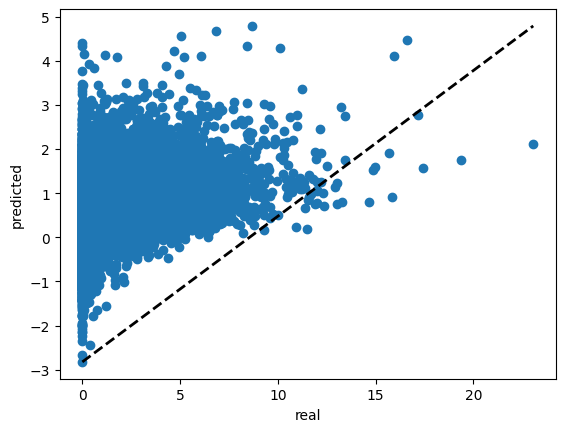

In [14]:
# plsregression
plsr = PLSRegression(n_components=50)
plsr.fit(x_train,y_train)

y_pred = plsr.predict(x_test)

# score = plsr.score(x_test,y_test) # score is 1, best
# print(score)
cor = []
for i in range(y_test.shape[0]):
    cor_ = pearsonr(y_pred[i],y_test[i])
    cor.append(cor_[0])
cor_mean = np.mean(np.array(cor))
cor_std = np.std(np.array(cor))
print(cor_mean, cor_std)
print(np.max(cor),np.min(cor))

plt.scatter(y_test,y_pred)
plt.xlabel('real')
plt.ylabel('predicted')
plt.plot([y_test.min(),y_test.max()],[y_pred.min(),y_pred.max()],'k--',lw=2)
plt.show()


0.3396196588482784


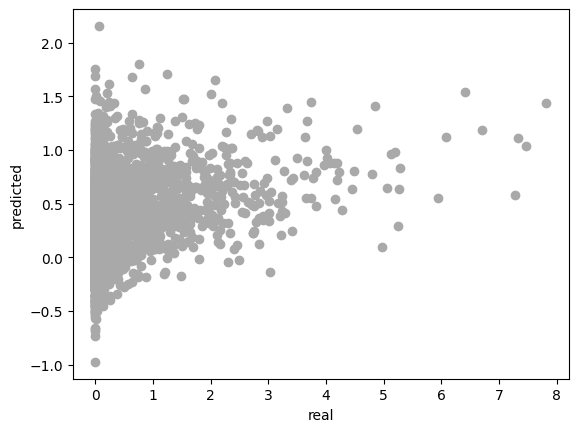

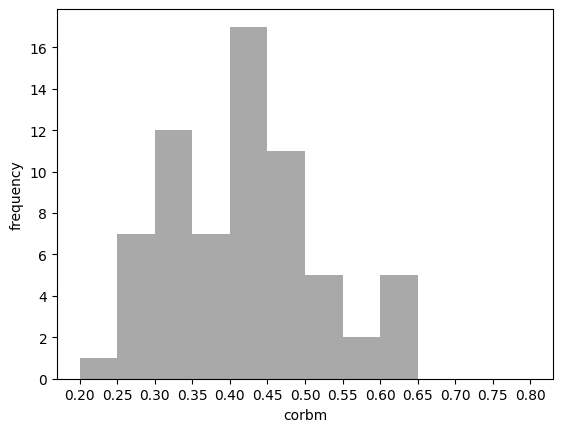

In [15]:
IDX = 1
plt.scatter(y_test[IDX],y_pred[IDX],c='darkgrey')
print(np.array(cor)[IDX])
plt.xlabel('real')
plt.ylabel('predicted')
# plt.plot([y_test.min(),y_test.max()],[y_pred.min(),y_pred.max()],'k--',lw=2)
plt.show()

# histogram of correlation in test set
d = 0.05
num_bin = np.arange(0.2,0.8,d)
#print(max(a)-min(a),max(a),min(a))

# plt.figure(figsize=(16,6),dpi=80)
plt.hist(np.array(cor), num_bin,color='darkgrey')
plt.xticks(num_bin)
plt.xlabel('corbm')
plt.ylabel('frequency')
#     plt.title('property histogram',size=15)
#     plt.grid(alpha=0.4)
plt.show()

In [11]:
# give a test
y_pred = plsr.predict(x_test)
print()
x_mean = np.mean(x_train,axis=0)
x = x_test - x_mean # centerize

y_pred_ = np.dot(x,plsr.coef_.T) #+plsr.intercept_
cor = []
for i in range(y_test.shape[0]):
    cor_ = pearsonr(y_pred_[i],y_pred[i])
    cor.append(cor_[0])
cor_mean = np.mean(np.array(cor))
cor_std = np.std(np.array(cor))
print(cor_mean, cor_std)
print(np.max(cor),np.min(cor))



0.9176215265307791 0.028462430578372114
0.9633572856847881 0.8074473851633135


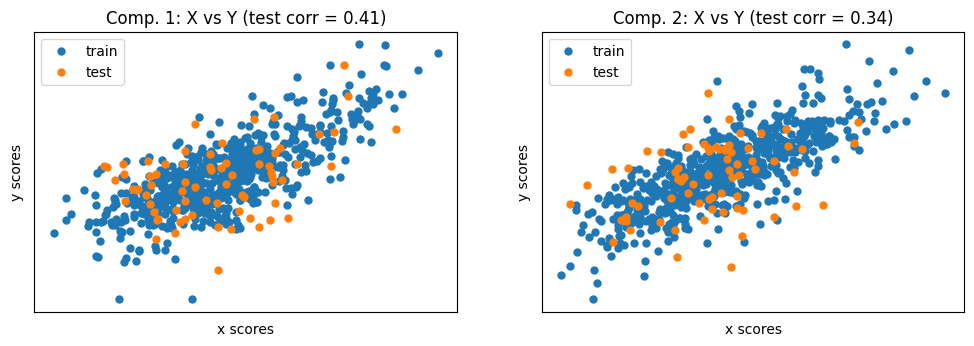

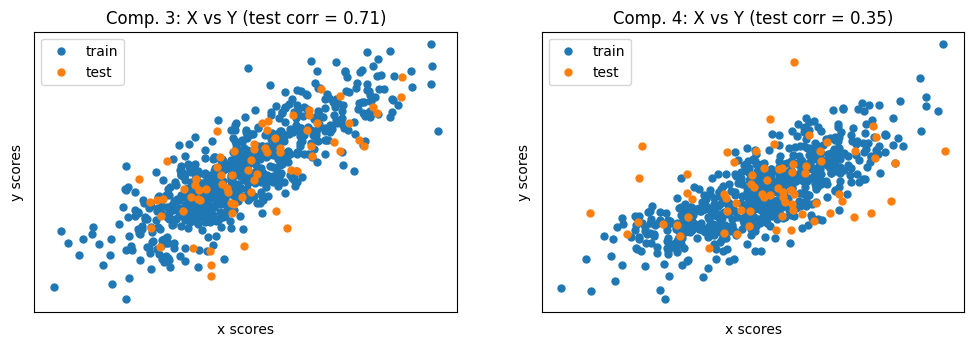

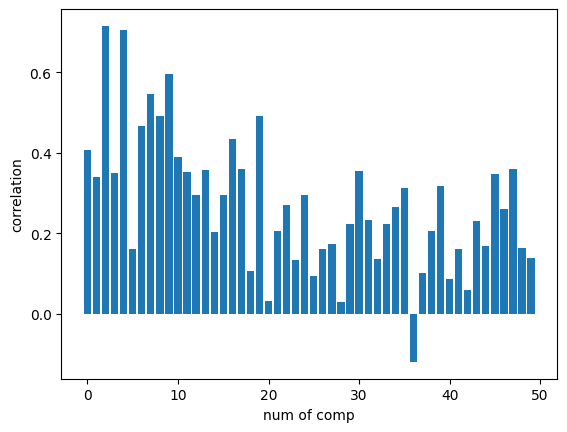

In [12]:
x_trc, y_trc = plsr.transform(x_train, y_train)
x_tec, y_tec = plsr.transform(x_test,y_test) #(72,50),(72,50)

# On diagonal plot X vs Y scores on each components
plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.scatter(x_trc[:, 0], y_trc[:, 0], label="train", marker="o", s=25)
plt.scatter(x_tec[:, 0], y_tec[:, 0], label="test", marker="o", s=25)
plt.xlabel("x scores")
plt.ylabel("y scores")
plt.title(
    "Comp. 1: X vs Y (test corr = %.2f)"
    % np.corrcoef(x_tec[:, 0], y_tec[:, 0])[0, 1]
)
plt.xticks(())
plt.yticks(())
plt.legend(loc="best")

plt.subplot(222)
plt.scatter(x_trc[:, 1], y_trc[:, 1], label="train", marker="o", s=25)
plt.scatter(x_tec[:, 1], y_tec[:, 1], label="test", marker="o", s=25)
plt.xlabel("x scores")
plt.ylabel("y scores")
plt.title(
    "Comp. 2: X vs Y (test corr = %.2f)"
    % np.corrcoef(x_tec[:, 1], y_tec[:, 1])[0, 1]
)
plt.xticks(())
plt.yticks(())
plt.legend(loc="best")

# On diagonal plot X vs Y scores on each components
plt.figure(figsize=(12, 8))
plt.subplot(223)
plt.scatter(x_trc[:, 2], y_trc[:, 2], label="train", marker="o", s=25)
plt.scatter(x_tec[:, 2], y_tec[:, 2], label="test", marker="o", s=25)
plt.xlabel("x scores")
plt.ylabel("y scores")
plt.title(
    "Comp. 3: X vs Y (test corr = %.2f)"
    % np.corrcoef(x_tec[:, 2], y_tec[:, 2])[0, 1]
)
plt.xticks(())
plt.yticks(())
plt.legend(loc="best")

plt.subplot(224)
plt.scatter(x_trc[:, 3], y_trc[:, 3], label="train", marker="o", s=25)
plt.scatter(x_tec[:, 3], y_tec[:, 3], label="test", marker="o", s=25)
plt.xlabel("x scores")
plt.ylabel("y scores")
plt.title(
    "Comp. 4: X vs Y (test corr = %.2f)"
    % np.corrcoef(x_tec[:, 3], y_tec[:, 3])[0, 1]
)
plt.xticks(())
plt.yticks(())
plt.legend(loc="best")
plt.show()

corc = []
for i in range(50):
    cor = np.corrcoef(x_tec[:,i],y_tec[:,i])
    corc.append(cor[0,1])
x = np.arange(50)
y = np.array(corc)
plt.bar(x,y)
plt.xlabel('num of comp')
plt.ylabel('correlation')
plt.show()

(4096, 4510)


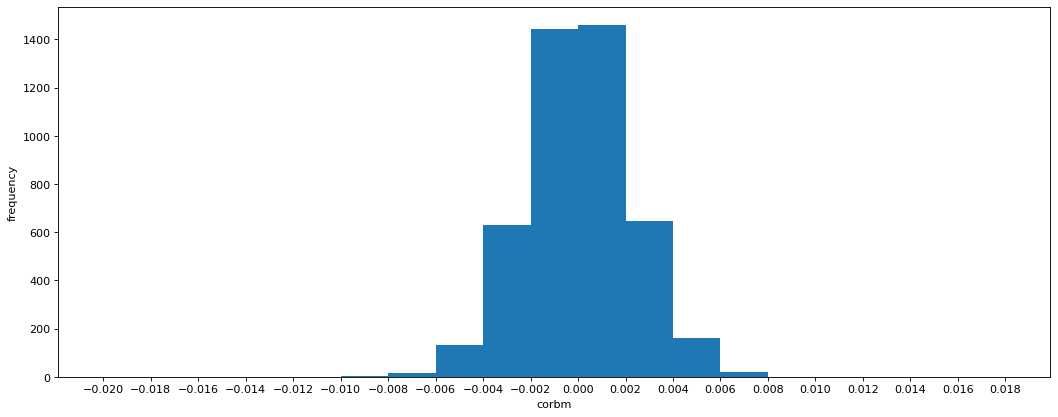

In [17]:
mrx = plsr.coef_
print(mrx.shape) # (U,V)

d = 0.002
num_bin = np.arange(-0.02,0.02,d)
#print(max(a)-min(a),max(a),min(a))

plt.figure(figsize=(16,6),dpi=80)
IDX = 3500
plt.hist(mrx[IDX,:], num_bin)
plt.xticks(num_bin)
plt.xlabel('corbm')
plt.ylabel('frequency')
#     plt.title('property histogram',size=15)
#     plt.grid(alpha=0.4)
plt.show()

(4096, 4510)
0.00021790605637645892 -7.841120310096711e-05 -0.00011756184437823567


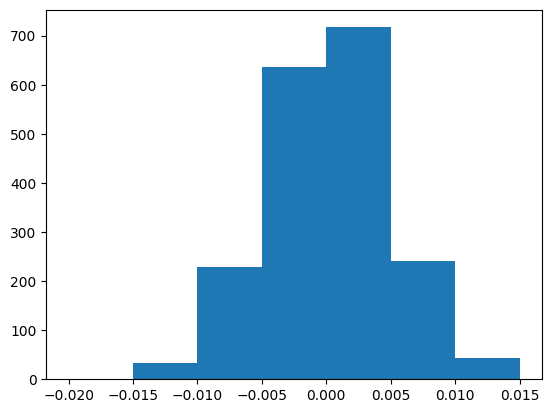

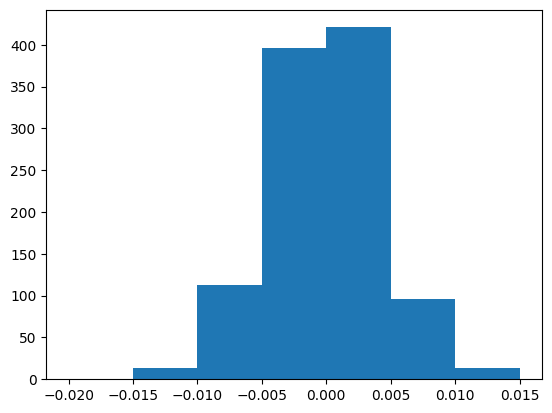

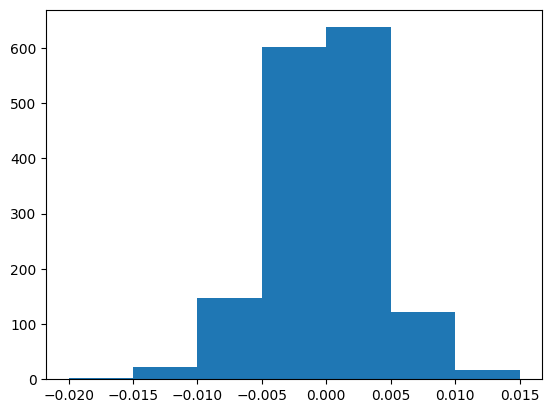

In [29]:
mrx = plsr.coef_
print(mrx.shape) # (U,V)

mrx_1 = mrx.T[idxb_clu1]
# mrx_1_vot = np.sum(mrx_1,axis=0)
mrx_2 = mrx.T[idxb_clu2]
mrx_3 = mrx.T[idxb_clu3]

d = 0.005
num_bin = np.arange(-0.02,0.02,d)
#print(max(a)-min(a),max(a),min(a))

plt.figure() # figsize=(16,6),dpi=80

IDX = idxm_clu1[500]
print(np.mean(mrx_1[:,IDX]),np.mean(mrx_2[:,IDX]),np.mean(mrx_3[:,IDX]))

plt.hist(mrx_1[:,IDX], num_bin)
plt.xticks(num_bin)
plt.show()

plt.hist(mrx_2[:,IDX], num_bin)
plt.xticks(num_bin)
plt.show()

plt.hist(mrx_3[:,IDX], num_bin)
plt.xticks(num_bin)
plt.show()



In [ ]:
# def clu lab to each unit
def cmp(x):
    lb = np.array([0,1,2])
    st = np.argsort(-x)
    lb = lb[st]
    x = x[st]
    dif1 = x[0]-x[1] # slope of dif1 bigger than dif2
    dif2 = x[1]-x[2]
    if x[0]>0 and dif1>=dif2:
        return lb[0],x[0]
    else:
        return -1,0

mrx = plsr.coef_
print(mrx.shape)
# nm = lys[7]+'_bra_plsr_wei.npz'
# np.savez(pjoin(fdir, lys[j], nm),data = mrx)

mrx_1 = mrx.T[idxb_clu1]
mrx_1_vot = np.mean(mrx_1,axis=0) # vote
mrx_2 = mrx.T[idxb_clu2]
mrx_2_vot = np.mean(mrx_2,axis=0)
mrx_3 = mrx.T[idxb_clu3]
mrx_3_vot = np.mean(mrx_3,axis=0)

bclum_lb = [] # unit label correpsonding to bra clu
bclum_vl = [] # unit value according to plsr.wei
for i in range(mrx.shape[0]):
    x = np.array([mrx_1_vot[i],mrx_2_vot[i],mrx_3_vot[i]])
    a,b = cmp(x)
    bclum_lb.append(a)
    bclum_vl.append(b)

# nm = lys[7]+'_b2m_thr_plsr_label3.npz'
# np.savez(pjoin(fdir, lys[j], nm),label = bclum_lb)


(4096, 4510)


(4096, 4510)
1055
1904
1551
851
808
695
1742


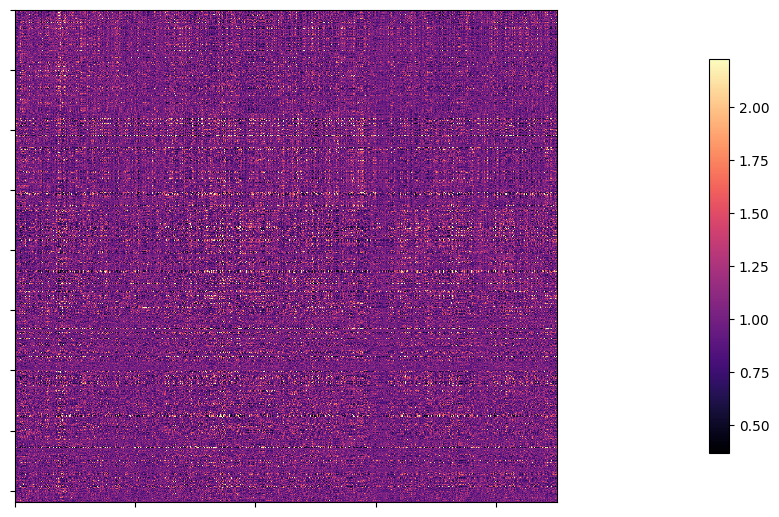

In [34]:
from nilearn import plotting

mrx = plsr.coef_
print(mrx.shape)

idxb = idxb_clu2+idxb_clu1+idxb_clu3
print(len(idxb_clu2))
print(len(idxb_clu1))
print(len(idxb_clu3))

# j = 7
# nm = lys[j]+'_b2m_thr_clu_label3.npz'
# yhat_ = np.load(pjoin(fdir, lys[j], nm))
# yhat = yhat_['label']
# bclum_lb_ = np.zeros(img_model_sub.shape[1])-1
# bclum_lb_[mk] = np.array(yhat)
idxm_clu1 = []
idxm_clu2 = []
idxm_clu3 = []
idxm_clux = []
for i in range(img_model_sub.shape[1]):
    if bclum_lb[i]==0:
        idxm_clu1.append(i)
    elif bclum_lb[i]==1:
        idxm_clu2.append(i)
    elif bclum_lb[i]==2:
        idxm_clu3.append(i)
    else:
        idxm_clux.append(i)
idxm = idxm_clu2+idxm_clu1+idxm_clu3+idxm_clux
print(len(idxm_clu2))
print(len(idxm_clu1))
print(len(idxm_clu3))
print(len(idxm_clux))

mrx_ = mrx[idxm]
mrx__ = mrx_.T[idxb].T
fig = plt.figure(figsize=(15,5))
plotting.plot_matrix(np.exp(mrx__*100),colorbar=True,cmap='magma',vmax=np.exp(0.008*100),vmin=np.exp(-0.01*100),figure = fig) # 
# plotting.show()
plt.show()

(4096, 4510)
(4510, 4096)


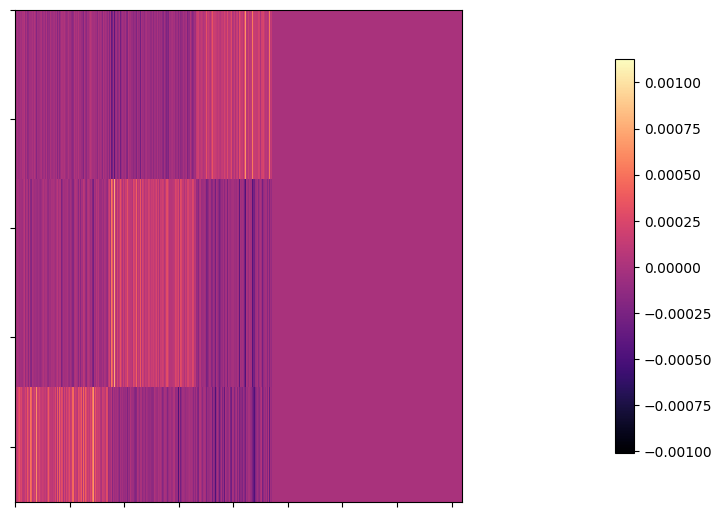

In [97]:
mrx = plsr.coef_
print(mrx.shape) # (u,v)

mrx_ = mrx[idxm] # 
mrx_1 = np.mean(mrx_.T[idxb_clu1],axis=0) #(u_,)
mrx_1_rep = np.tile(mrx_1,len(idxb_clu1)).reshape(-1,mrx_1.shape[0]) # (v_,u_)
mrx_2 = np.mean(mrx_.T[idxb_clu2],axis=0)
mrx_2_rep = np.tile(mrx_2,len(idxb_clu2)).reshape(-1,mrx_2.shape[0]) # (v_,u_)
mrx_3 = np.mean(mrx_.T[idxb_clu3],axis=0)
mrx_3_rep = np.tile(mrx_3,len(idxb_clu3)).reshape(-1,mrx_3.shape[0]) # (v_,u_)
mrx__ = np.append(mrx_3_rep,mrx_1_rep,axis=0)
mrx__ = np.append(mrx__,mrx_2_rep,axis=0)
print(mrx__.shape)

fig = plt.figure(figsize=(15,5))
plotting.plot_matrix(mrx__,colorbar=True,cmap='magma',figure = fig) # 
# plotting.show()
plt.show()


findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


transform matrix shape  (4096, 5)
[[ 24.27454586 -54.39666068 -20.93424189]
 [ 39.45019074  44.55318034  18.48796761]
 [-61.69145073   7.55906048   1.07079656]]


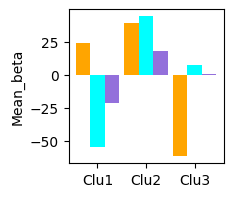

In [33]:
# prop pattern
import matplotlib.pyplot as plt

i = 6
fdir = pjoin(basedir, r'property_analysis/derivatives/cnn-som/prop-pcs_alex')
wei_f = pjoin(fdir, lys[i],f'encoding_training_result.mat')
weigh = h5py.File(wei_f)
#     print(weigh.keys())
weigh_mrx = weigh['thetaFinal']
weigh_mrx = np.array(weigh_mrx)
print('transform matrix shape ', weigh_mrx.shape) # (4096,5)

clu1 = weigh_mrx[idxm_clu1,:3]
clu2 = weigh_mrx[idxm_clu2,:3]
clu3 = weigh_mrx[idxm_clu3,:3]

wei_clu1_col = np.mean(clu1,axis=0)*1000 # (3,)
wei_clu2_col = np.mean(clu2,axis=0)*1000
wei_clu3_col = np.mean(clu3,axis=0)*1000

wei_clu_col = [] 
wei_clu_col.append(wei_clu2_col)
wei_clu_col.append(wei_clu1_col)
wei_clu_col.append(wei_clu3_col)
wei_clu_col = np.array(wei_clu_col)
print(wei_clu_col)
# [[ 237.49099968   52.97494511   41.23299597]
#  [  34.70398187 -260.01369762 -109.16882459]
#  [ -58.46024717  128.67514709   20.96782858]]

xlb = ['Clu1', 'Clu2', 'Clu3']
x = np.arange(len(xlb))
width = 0.3
ly2 = x - width
ly3 = x
ly4 = x + width

plt.figure(figsize=(2,2)) # ,dpi=300
plt.rc('font',family='Arial', size=10)
plt.bar(ly2,wei_clu_col.T[0],width=width,color="orange",label='PC1')
plt.bar(ly3,wei_clu_col.T[1],width=width,color="cyan",label='PC2')
plt.bar(ly4,wei_clu_col.T[2],width=width,color="mediumpurple",label='PC3')

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=xlb,fontproperties=font_dict)
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('Mean_beta',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection')
plt.show()
plt.close()


In [28]:
# PLSR with Cornet-S

# trial6 PLSR between model and brain
# so could get bra clu voxel wei to each mdl unit

# prepare brain data
import os
import h5py
import numpy as np
import scipy.io as scio
import matplotlib.pyplot as plt
from os.path import join as pjoin
# from nilearn.masking import apply_mask, unmask

basedir = r'/n02dat01/users/qdzhao/THINGS'
sub = '03'

outdir_ = pjoin(basedir, r'property_analysis/derivatives/2_pro_relation')
ind = scio.loadmat(pjoin(outdir_, f'index_1854to720.mat'))
ind_1854to720 = ind['index_1854to720'][0].squeeze().tolist()

f_dir = pjoin(basedir, r'property_analysis/derivatives/linear_model','sub-'+sub)
# p value of training set
adjp_f = pjoin(f_dir, 'prop_pcs', f'cross_validation_permutation_result.mat')
adjp = h5py.File(adjp_f)
print(adjp.keys())
adjp_ = adjp['adj_p']
adj_p = np.squeeze(adjp_)

cor_f = pjoin(f_dir, 'prop_pcs', f'model_test_result.mat')
corf = h5py.File(cor_f)
print(corf.keys())
cor_ = corf['R']
cor = np.squeeze(cor_) # r value

# # prop pcs selection of each voxel in each ROI
# wei_f = pjoin(f_dir, 'prop_pcs','encoding_training_result.mat')
# weif = h5py.File(wei_f) # encoding weight
# print(weif.keys())
# wei_ = weif['thetaFinal']
# wei = np.squeeze(wei_)
# print(wei.shape) #(V,5)

mkb = [] # sig mask of brain
for j in range(len(adj_p)):
    if adj_p[j]<0.05 and cor[j]>0.05:
        mkb.append(j)
# wei_s = wei[mkb,:3]

# prop selection in each cluster

yhat_ = np.load(pjoin(f_dir,'prop_pcs','volume_pc_clu_label3.npz'))
yhat = yhat_['label']

idxb_clu1 = [] # idx of brain for each clu
idxb_clu2 = []
idxb_clu3 = []

for i in range(len(mkb)):
    if yhat[i] == 0:
        idxb_clu1.append(i)
    if yhat[i] == 1:
        idxb_clu2.append(i)
    if yhat[i] == 2:
        idxb_clu3.append(i)

# weib_clu1 = wei_s[idxb_clu1] # (1904,3)
# weib_clu2 = wei_s[idxb_clu2] # (1055,3)
# weib_clu3 = wei_s[idxb_clu3] # (1551,3)

# prepare brain activation
betas_csv_dir = pjoin(basedir, r'THINGS_fMRI/betas_csv')
betas_concept_ = scio.loadmat(pjoin(betas_csv_dir, f'sub-{sub}_betas_concept.mat'))
betas_concept =  betas_concept_['data'] # (V,720)
print(betas_concept.shape)
                              
# actb_clu1 = betas_concept[mkb][idxb_clu1].T
# # print(act_clu1.shape) # (720,1904)
# actb_clu2 = betas_concept[mkb][idxb_clu2].T
# # print(act_clu2.shape) # (720,1055)
# actb_clu3 = betas_concept[mkb][idxb_clu3].T
# # print(act_clu3.shape) # # (720,1551)
# # act_clu = [act_clu1,act_clu2,act_clu3]

# prepare model activation
lys = ['V1', 'V2', 'V4', 'IT', 'decoder']
img_fea_dir = pjoin(basedir, r'THINGS_stimuli/THINGS/derivatives/dnn_feature_maps/cornet-s')
img_partitions = os.listdir(img_fea_dir)
img_partitions.sort()
img_fea = []
for p in img_partitions:
    part_dir = os.path.join(img_fea_dir, p)
    fea = np.load(part_dir,allow_pickle=True) # 
    fea_ = fea.tolist()
    img_fea.append(fea_['IT'].flatten())
#     img_fea.append(fea_['fc8'])
img_model_ = np.array(img_fea)
#     img_alex = img_fea_[obj12_df.index]
img_model_sub = img_model_[ind_1854to720]
print(img_model_sub.shape) #(720,4096)
img_model_sub = img_model_sub
# actm_clu1 = img_model_sub[mk][idx_clu1].T # model activation for each clu
# actm_clu2 = img_model_sub[mk][idx_clu2].T
# actm_clu3 = img_model_sub[mk][idx_clu3].T

<KeysViewHDF5 ['adj_p', 'mask', 'trial_sum_all']>
<KeysViewHDF5 ['R', 'X_pred', 'betas_test']>
(720, 189164)
(720, 25088)


In [29]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

print(betas_concept.T[mkb].shape) #(4510, 720)
print(img_model_sub.shape) #(720,4096)
x = betas_concept.T[mkb].T
y = img_model_sub
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1, random_state=97)


(2299, 720)
(720, 25088)


0.5076172415651716 0.10497995728781172
0.7125257084593212 0.2062398587831515


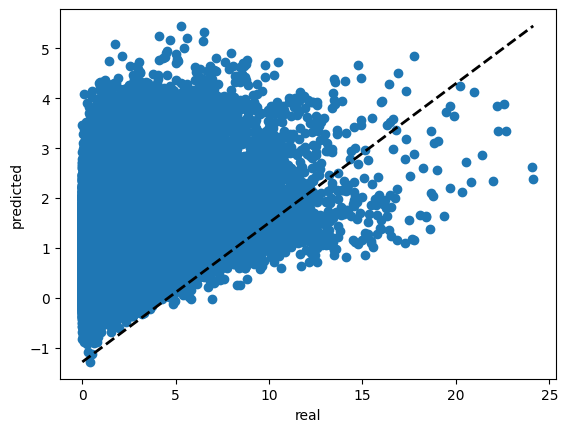

In [30]:
# plsregression
plsr = PLSRegression(n_components=50)
plsr.fit(x_train,y_train)

y_pred = plsr.predict(x_test)

# score = plsr.score(x_test,y_test) # score is 1, best
# print(score)
cor = []
for i in range(y_test.shape[0]):
    cor_ = pearsonr(y_pred[i],y_test[i])
    cor.append(cor_[0])
cor_mean = np.mean(np.array(cor))
cor_std = np.std(np.array(cor))
print(cor_mean, cor_std)
print(np.max(cor),np.min(cor))

plt.scatter(y_test,y_pred)
plt.xlabel('real')
plt.ylabel('predicted')
plt.plot([y_test.min(),y_test.max()],[y_pred.min(),y_pred.max()],'k--',lw=2)
plt.show()


In [ ]:
# plsr perf for three subs
# corn_perf = np.array([0.53,0.52,0.50])

# sub-01
0.5321386601984112 0.09568763421187797
0.7506526973666225 0.266623420745382
# sub-02
0.5200717838422306 0.10501491953477964
0.7260084491488183 0.22093104917387774
# sub-03
0.5076172415651716 0.10497995728781172
0.7125257084593212 0.2062398587831515

In [37]:
# PLSR with resnet50

# trial6 PLSR between model and brain
# so could get bra clu voxel wei to each mdl unit

# prepare brain data
import os
import h5py
import numpy as np
import scipy.io as scio
import matplotlib.pyplot as plt
from os.path import join as pjoin
# from nilearn.masking import apply_mask, unmask

basedir = r'/n02dat01/users/qdzhao/THINGS'
sub = '03'

outdir_ = pjoin(basedir, r'property_analysis/derivatives/2_pro_relation')
ind = scio.loadmat(pjoin(outdir_, f'index_1854to720.mat'))
ind_1854to720 = ind['index_1854to720'][0].squeeze().tolist()

f_dir = pjoin(basedir, r'property_analysis/derivatives/linear_model','sub-'+sub)
# p value of training set
adjp_f = pjoin(f_dir, 'prop_pcs', f'cross_validation_permutation_result.mat')
adjp = h5py.File(adjp_f)
print(adjp.keys())
adjp_ = adjp['adj_p']
adj_p = np.squeeze(adjp_)

cor_f = pjoin(f_dir, 'prop_pcs', f'model_test_result.mat')
corf = h5py.File(cor_f)
print(corf.keys())
cor_ = corf['R']
cor = np.squeeze(cor_) # r value

# # prop pcs selection of each voxel in each ROI
# wei_f = pjoin(f_dir, 'prop_pcs','encoding_training_result.mat')
# weif = h5py.File(wei_f) # encoding weight
# print(weif.keys())
# wei_ = weif['thetaFinal']
# wei = np.squeeze(wei_)
# print(wei.shape) #(V,5)

mkb = [] # sig mask of brain
for j in range(len(adj_p)):
    if adj_p[j]<0.05 and cor[j]>0.05:
        mkb.append(j)
# wei_s = wei[mkb,:3]

# prop selection in each cluster

yhat_ = np.load(pjoin(f_dir,'prop_pcs','volume_pc_clu_label3.npz'))
yhat = yhat_['label']

idxb_clu1 = [] # idx of brain for each clu
idxb_clu2 = []
idxb_clu3 = []

for i in range(len(mkb)):
    if yhat[i] == 0:
        idxb_clu1.append(i)
    if yhat[i] == 1:
        idxb_clu2.append(i)
    if yhat[i] == 2:
        idxb_clu3.append(i)

# weib_clu1 = wei_s[idxb_clu1] # (1904,3)
# weib_clu2 = wei_s[idxb_clu2] # (1055,3)
# weib_clu3 = wei_s[idxb_clu3] # (1551,3)

# prepare brain activation
betas_csv_dir = pjoin(basedir, r'THINGS_fMRI/betas_csv')
betas_concept_ = scio.loadmat(pjoin(betas_csv_dir, f'sub-{sub}_betas_concept.mat'))
betas_concept =  betas_concept_['data'] # (V,720)
print(betas_concept.shape)
                              
# actb_clu1 = betas_concept[mkb][idxb_clu1].T
# # print(act_clu1.shape) # (720,1904)
# actb_clu2 = betas_concept[mkb][idxb_clu2].T
# # print(act_clu2.shape) # (720,1055)
# actb_clu3 = betas_concept[mkb][idxb_clu3].T
# # print(act_clu3.shape) # # (720,1551)
# # act_clu = [act_clu1,act_clu2,act_clu3]

# prepare model activation
lys = ['block1', 'block2', 'block3', 'block4', 'fc']
img_fea_dir = pjoin(basedir, r'THINGS_stimuli/THINGS/derivatives/dnn_feature_maps/resnet50')
img_partitions = os.listdir(img_fea_dir)
img_partitions.sort()
img_fea = []
for p in img_partitions:
    part_dir = os.path.join(img_fea_dir, p)
    fea = np.load(part_dir,allow_pickle=True)
    fea_ = fea.tolist()
    img_fea.append(fea_['block4'].flatten())
#     img_fea.append(fea_['fc8'])
img_model_ = np.array(img_fea)
#     img_alex = img_fea_[obj12_df.index]
img_model_sub = img_model_[ind_1854to720]
print(img_model_sub.shape) #(720,4096)
img_model_sub = img_model_sub
# actm_clu1 = img_model_sub[mk][idx_clu1].T # model activation for each clu
# actm_clu2 = img_model_sub[mk][idx_clu2].T
# actm_clu3 = img_model_sub[mk][idx_clu3].T

<KeysViewHDF5 ['adj_p', 'mask', 'trial_sum_all']>
<KeysViewHDF5 ['R', 'X_pred', 'betas_test']>
(720, 189164)
(720, 100352)


In [38]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

print(betas_concept.T[mkb].shape) #(4510, 720)
print(img_model_sub.shape) #(720,4096)
x = betas_concept.T[mkb].T
y = img_model_sub
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1, random_state=97)


(2299, 720)
(720, 100352)


0.5051467369872323 0.10043813270543508
0.7216798496872774 0.2852385694348285


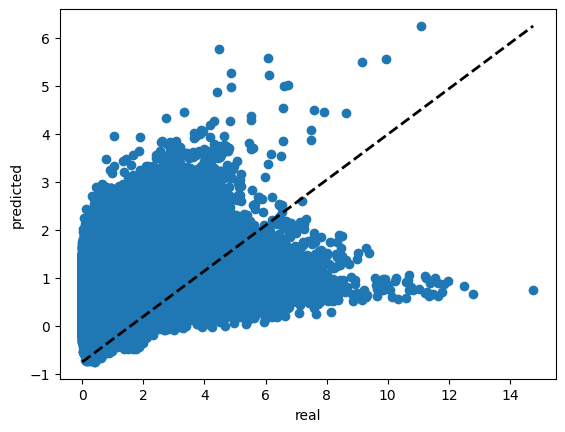

In [39]:
# plsregression
plsr = PLSRegression(n_components=50)
plsr.fit(x_train,y_train)

y_pred = plsr.predict(x_test)

# score = plsr.score(x_test,y_test) # score is 1, best
# print(score)
cor = []
for i in range(y_test.shape[0]):
    cor_ = pearsonr(y_pred[i],y_test[i])
    cor.append(cor_[0])
cor_mean = np.mean(np.array(cor))
cor_std = np.std(np.array(cor))
print(cor_mean, cor_std)
print(np.max(cor),np.min(cor))

plt.scatter(y_test,y_pred)
plt.xlabel('real')
plt.ylabel('predicted')
plt.plot([y_test.min(),y_test.max()],[y_pred.min(),y_pred.max()],'k--',lw=2)
plt.show()


In [ ]:
# plsr perf for three sub
# resn_perf = np.array([0.53,0.52,0.51])

# sub-01
0.5281210645923942 0.0971473557205352
0.740833093701333 0.23918465160499244
# sub-02
0.5161243633526696 0.10360283309324118
0.712536685341162 0.2473181420683786
# sub-03
0.5051467369872323 0.10043813270543508
0.7216798496872774 0.2852385694348285

In [ ]:
#############################################################################

In [90]:
# classification analysis
import os
import torch
import pandas as pd
import numpy as np
import scipy.io as scio
from os.path import join as pjoin
from sklearn.decomposition import PCA

basedir = r'/n02dat01/users/qdzhao/THINGS'
outdir_ = pjoin(basedir, r'property_analysis/derivatives/2_pro_relation')
ind = scio.loadmat(pjoin(outdir_, f'index_1854to720.mat'))
ind_1854to720 = ind['index_1854to720'][0].squeeze().tolist()

#label
obj_tsv=pjoin(basedir, r'THINGS_stimuli/THINGS',f'things_concepts.tsv')
obj_df = pd.read_csv(obj_tsv, sep='\t')['Word'].tolist()
obj_df_720 = np.array(obj_df)[ind_1854to720].tolist()

lys = ['maxpool1', 'maxpool2', 'relu3', 'relu4', 'maxpool5', 'relu6' , 'relu7']

# #data
# img_fea_dir = pjoin(basedir, r'property_analysis/derivatives/cnn-som/prop-pcs_tdann/cat_feat')
# img_partitions = os.listdir(img_fea_dir)
# img_partitions.sort()
# img_fea = []
# img_nm = []
# for p in img_partitions:
#     img_nm.append(p.split('.')[0])
#     part_dir = os.path.join(img_fea_dir, p)
#     fea = np.load(part_dir,allow_pickle=True)
#     fea_ = fea.tolist()
#     # img_fea_ = []
#     for id in range(12):
#         img_fea.append(fea_[id]['layer4.1'].squeeze()) # (12,4096)*16
# img_fea_ori = np.array(img_fea)

# print(img_fea_ori.shape) # (216,25088) 216=18*12
# # pca = PCA(n_components=50) #降到 50 维
# # img_fea_ori_50 = pca.fit_transform(img_fea_ori)
# # print(np.sum(pca.explained_variance_ratio_))
# print(img_nm)

# cat1 = ['face','baby','boy','girl','arm','foot','leg','hip']
# cat2 = ['car','bus','piano','phone','pillow','ship']
# cat3 = ['cloud','doghouse','tree','snow']


# training set for classifier
cat1 = ['watch', 'snake', 'hamster', 'platypus', 'face', 'grasshopper', 'dolphin', 'fish', 'gargoyle', 'kimono']
cat2 = ['lock', 'pliers', 'projector', 'waffle iron', 'mosquito net', 'wrench', 'kite', 'broom', 'washboard', 'game']
cat3 = ['pogo stick', 'pothole', 'hovercraft', 'stalagmite', 'trap', 'railing', 'bench', 'ladder', 'hedge']
img_nm = cat1+cat2+cat3
target_cats = [['animal',cat1],['object',cat2],['scene',cat3]] # ,['others]
# feature extracted from F:\visual_project\THINGS_project\animacy_analysis\code\model_feature_extraction.ipynb

cats_num = [] # sorted by alphabetas
for j in range(len(img_nm)):
    if img_nm[j] in cat1:
        cats_num.append([0]) # animal
    elif img_nm[j] in cat2:
        cats_num.append([1]) # object
    elif img_nm[j] in cat3:
        cats_num.append([2]) # scene
        # cats_num.append([2]*12) # scene
    # else:
    #     cats_num.append([4]*12)

cats_num = np.array(cats_num)#.flatten()
# print(cats_num.shape) # 21

cat_idx2 = []
for i in range(len(img_nm)):
    cat_idx2.append(obj_df_720.index(img_nm[i]))



In [91]:
# tri classification algorithm using plsr predited img features
# classifier train
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# plsr
# print(betas_concept.T[mkb].shape) #(4510, 720)
x_mean = np.mean(x_train,axis=0)
x = betas_concept[cat_idx2].T
x = x[mkb].T
x = x - x_mean # centerize
print(x.shape) #(n,4510)

coef = plsr.coef_
# # coef[idxm_clux]=0
y_pred = np.dot(x, coef.T)
# y_pred = plsr.predict(x)
# y_pred.T[idxm_clux] = 0

# classifier
X=y_pred
print(X.shape)
Y=cats_num+0

# X = StandardScaler().fit_transform(X)
lr = LogisticRegression()   # Logistic回归模型
lr.fit(X, Y) 

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

id1 = []
id2 = []
id3 = []
for i in range(Y.shape[0]):
    if Y[i] == 0:
        id1.append(i)
    if Y[i] == 1:
        id2.append(i)
    if Y[i] == 2:
        id3.append(i)

acc_ori_1 = np.mean(result[id1])
print('acc_ori_ani: %.2f%%' % (100 * acc_ori_1))
acc_ori_2 = np.mean(result[id2])
print('acc_ori_obj: %.2f%%' % (100 * acc_ori_2))
acc_ori_3 = np.mean(result[id3])
print('acc_ori_sce: %.2f%%' % (100 * acc_ori_3))

acc_ori = np.array([acc_ori_3, acc_ori_1, acc_ori_2])

# x = np.arange(3)
# xlb = ['Sce', 'Ani', 'Obj']
# width = 0.3

# plt.figure(figsize=(2,2)) # ,dpi=300
# plt.rc('font',family='Arial', size=10)

# plt.bar(x,acc_ori,width=width,color="grey") # ,yerr=std_score_bm

# font_dict = {'family':'Arial', 'size':10}
# plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# # plt.xlabel('Cluster',fontdict=font_dict)
# plt.ylabel('acc',fontdict=font_dict)
# # plt.legend(loc='best',prop=font_dict)
# # plt.title('ROI prop selection') 
# plt.show()
# plt.close()


(29, 4510)
(29, 4096)


/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


acc_ori_ani: 100.00%
acc_ori_obj: 100.00%
acc_ori_sce: 100.00%


(19, 4510)
(19, 4096)
acc_pred_ani: 100.00%
acc_pred_obj: 85.71%
acc_pred_sce: 80.00%
[0.8        1.         0.85714286]


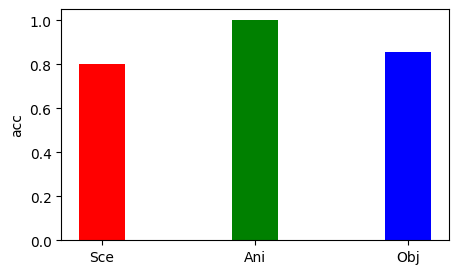

In [92]:
# classification accyracy of y_pred using plsr
# classifier test
import h5py
import pandas as pd
import scipy.io as scio
from os.path import join as pjoin

basedir = r'/n02dat01/users/qdzhao/THINGS'
obj_tsv=pjoin(basedir, r'THINGS_stimuli/THINGS',f'things_concepts.tsv')
obj_df = pd.read_csv(obj_tsv, sep='\t')['Word'].tolist()
obj_df_720 = np.array(obj_df)[ind_1854to720].tolist()

# testing set for classifier
cat1 = ['sloth', 'whale', 'manatee', 'snail', 'girl', 'toucan', 'lobster']
cat2 = ['face mask', 'dustpan', 'pogo stick', 'bracket', 'playing card', 'stair', 'scanner']
cat3 = ['hammock', 'submarine', 'tarp', 'carousel', 'solar panel', ]
img_nm = cat1+cat2+cat3
target_cats = [['animal',cat1],['object',cat2],['scene',cat3]] # ,['others]
# feature extracted from F:\visual_project\THINGS_project\animacy_analysis\code\model_feature_extraction.ipynb

cats_num = [] # sorted by alphabetas
for j in range(len(img_nm)):
    if img_nm[j] in cat1:
        cats_num.append([0]) # animal
    elif img_nm[j] in cat2:
        cats_num.append([1]) # object
    elif img_nm[j] in cat3:
        cats_num.append([2]) # scene
    # else:
    #     cats_num.append([4]*12)

cats_num = np.array(cats_num).flatten()

cat_idx2 = []
for i in range(len(img_nm)):
    cat_idx2.append(obj_df_720.index(img_nm[i]))

# plsr
x_mean = np.mean(x_train,axis=0)
x = betas_concept[cat_idx2].T
x = x[mkb].T
x = x - x_mean # centerize
print(x.shape) #(30,4510)
coef = plsr.coef_
# coef[idxm_clux]=0
y_pred = np.dot(x, coef.T)
# y_pred = plsr.predict(x)
# y_pred.T[idxm_clux] = 0

# classifier
X=y_pred
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

id1 = []
id2 = []
id3 = []
for i in range(Y.shape[0]):
    if Y[i] == 0:
        id1.append(i)
    if Y[i] == 1:
        id2.append(i)
    if Y[i] == 2:
        id3.append(i)

acc_ori_1 = np.mean(result[id1])
print('acc_pred_ani: %.2f%%' % (100 * acc_ori_1))
acc_ori_2 = np.mean(result[id2])
print('acc_pred_obj: %.2f%%' % (100 * acc_ori_2))
acc_ori_3 = np.mean(result[id3])
print('acc_pred_sce: %.2f%%' % (100 * acc_ori_3))

acc_ori = np.array([acc_ori_3, acc_ori_1, acc_ori_2])
print(acc_ori)

x = np.arange(3)
xlb = ['Sce', 'Ani', 'Obj']
width = 0.3

plt.figure(figsize=(5,3)) # ,dpi=300
plt.rc('font',family='Arial', size=10)

plt.bar(x,acc_ori,width=width,color=['red','green','blue']) # ,yerr=std_score_bm

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('acc',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection') 
plt.show()
plt.close()

(19, 4510)
(19, 4096)
(19, 4096)
(19, 4096)
[[0.6        0.85714286 0.85714286]
 [0.         1.         1.        ]
 [0.         0.71428571 0.85714286]]


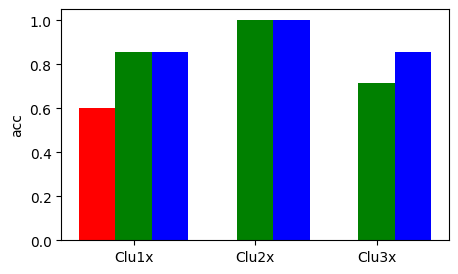

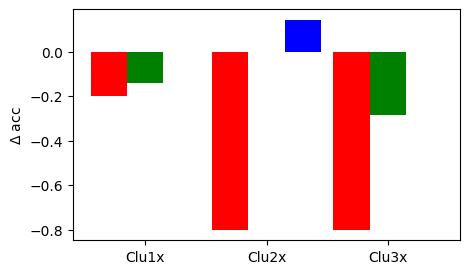

In [93]:
#3 each cluster effect to accuracy, keep only one clu each time

# id = 7
# nm = lys[id]+'_b2m_plsr_label3.npz'
# yhat_ = np.load(pjoin(fdir, lys[id], nm))
# yhat = yhat_['label'] # [0,1,2]

x_mean = np.mean(x_train,axis=0)
x = betas_concept[cat_idx2].T
x = x[mkb].T
x = x - x_mean # centerize
print(x.shape) #(30,4510)

coef = plsr.coef_
# coef[idxm_clux] = 0
coef_clu1x = coef + 0
coef_clu1x[idxm_clu3+idxm_clu2] = 0
y_pred_clu1x = np.dot(x, coef_clu1x.T)
coef_clu2x = coef + 0
coef_clu2x[idxm_clu1+idxm_clu3] = 0
y_pred_clu2x = np.dot(x, coef_clu2x.T)
coef_clu3x = coef + 0
coef_clu3x[idxm_clu1+idxm_clu2] = 0
y_pred_clu3x = np.dot(x, coef_clu3x.T)

# y_pred = plsr.predict(x)
# y_pred.T[idxm_clux] = 0
# y_pred_clu1x = y_pred+0
# y_pred_clu1x.T[idxm_clu3+idxm_clu2] = 0
# y_pred_clu2x = y_pred+0
# y_pred_clu2x.T[idxm_clu3+idxm_clu1] = 0
# y_pred_clu3x = y_pred+0
# y_pred_clu3x.T[idxm_clu1+idxm_clu2] = 0

id1 = []
id2 = []
id3 = []
for i in range(cats_num.shape[0]):
    if cats_num[i] == 0:
        id1.append(i)
    if cats_num[i] == 1:
        id2.append(i)
    if cats_num[i] == 2:
        id3.append(i)

#############################################1 img_fea_clu1x

X=y_pred_clu1x
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu1x_1 = np.mean(result[id1])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_1))
acc_clu1x_2 = np.mean(result[id2])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_2))
acc_clu1x_3 = np.mean(result[id3])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_3))

################################################2 img_fea_clu2x

X=y_pred_clu2x
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu2x_1 = np.mean(result[id1])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_1))
acc_clu2x_2 = np.mean(result[id2])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_2))
acc_clu2x_3 = np.mean(result[id3])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_3))

#################################################3 img_fea_clu3x

X=y_pred_clu3x
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu3x_1 = np.mean(result[id1])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_1))
acc_clu3x_2 = np.mean(result[id2])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_2))
acc_clu3x_3 = np.mean(result[id3])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_3))

acc_ori = np.array([acc_ori_3,acc_ori_1,acc_ori_2])
acc_clux_ = np.array([[acc_clu2x_3,acc_clu2x_1,acc_clu2x_2],[acc_clu1x_3,acc_clu1x_1,acc_clu1x_2],[acc_clu3x_3,acc_clu3x_1,acc_clu3x_2]])
acc_clux = acc_clux_ + 0
for i in range(3):
    acc_clux[i] = acc_clux_[i] - acc_ori
print(acc_clux_)

xlb = ['Clu1x', 'Clu2x', 'Clu3x']
x = np.arange(len(xlb))
width = 0.3
ly2 = x - width
ly3 = x
ly4 = x + width

plt.figure(figsize=(5,3)) # ,dpi=300
plt.rc('font',family='Arial', size=10)
plt.bar(ly2,acc_clux_.T[0],width=width,color="red",label='Sce') # ,yerr=std_score_bm
plt.bar(ly3,acc_clux_.T[1],width=width,color="green",label='Ani')
plt.bar(ly4,acc_clux_.T[2],width=width,color="blue",label='Obj')

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('acc',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection') 
plt.show()

plt.figure(figsize=(5,3)) # ,dpi=300
plt.rc('font',family='Arial', size=10)
plt.bar(ly2,acc_clux.T[0],width=width,color="red",label='Sce') # ,yerr=std_score_bm
plt.bar(ly3,acc_clux.T[1],width=width,color="green",label='Ani')
plt.bar(ly4,acc_clux.T[2],width=width,color="blue",label='Obj')

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('$\Delta$ acc',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection') 
plt.show()
plt.close()

(19, 4510)
(19, 4096)
(19, 4096)
(19, 4096)
[[0.2        1.         1.        ]
 [0.8        0.85714286 0.85714286]
 [0.6        1.         0.85714286]]


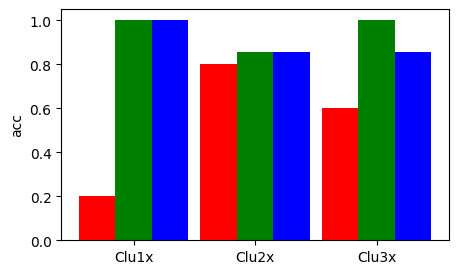

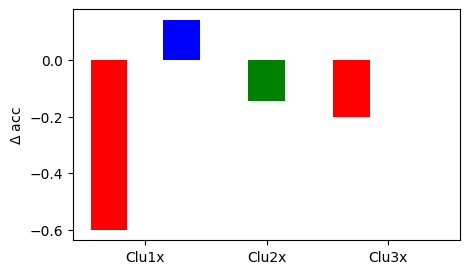

In [94]:
#4 cluster lesion to accuracy

# id = 7
# nm = lys[id]+'_b2m_plsr_label3.npz'
# yhat_ = np.load(pjoin(fdir, lys[id], nm))
# yhat = yhat_['label'] # [0,1,2]

x_mean = np.mean(x_train,axis=0)
x = betas_concept[cat_idx2].T
x = x[mkb].T
x = x - x_mean # centerize
print(x.shape) #(30,4510)

coef = plsr.coef_
# coef[idxm_clux] = 0
coef_clu1x = coef + 0
coef_clu1x[idxm_clu1] = 0
y_pred_clu1x = np.dot(x, coef_clu1x.T)
coef_clu2x = coef + 0
coef_clu2x[idxm_clu2] = 0
y_pred_clu2x = np.dot(x, coef_clu2x.T)
coef_clu3x = coef + 0
coef_clu3x[idxm_clu3] = 0
y_pred_clu3x = np.dot(x, coef_clu3x.T)

# y_pred = plsr.predict(x)
# y_pred.T[idxm_clux] = 0
# y_pred_clu1x = y_pred+0
# y_pred_clu1x.T[idxm_clu1] = 0
# y_pred_clu2x = y_pred+0
# y_pred_clu2x.T[idxm_clu2] = 0
# y_pred_clu3x = y_pred+0
# y_pred_clu3x.T[idxm_clu3] = 0

id1 = []
id2 = []
id3 = []
for i in range(cats_num.shape[0]):
    if cats_num[i] == 0:
        id1.append(i)
    if cats_num[i] == 1:
        id2.append(i)
    if cats_num[i] == 2:
        id3.append(i)

#############################################1 img_fea_clu1x

X=y_pred_clu1x
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu1x_1 = np.mean(result[id1])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_1))
acc_clu1x_2 = np.mean(result[id2])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_2))
acc_clu1x_3 = np.mean(result[id3])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_3))

################################################2 img_fea_clu2x

X=y_pred_clu2x
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu2x_1 = np.mean(result[id1])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_1))
acc_clu2x_2 = np.mean(result[id2])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_2))
acc_clu2x_3 = np.mean(result[id3])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_3))

#################################################3 img_fea_clu3x

X=y_pred_clu3x
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu3x_1 = np.mean(result[id1])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_1))
acc_clu3x_2 = np.mean(result[id2])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_2))
acc_clu3x_3 = np.mean(result[id3])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_3))

acc_ori = np.array([acc_ori_3,acc_ori_1,acc_ori_2])
acc_clux_ = np.array([[acc_clu2x_3,acc_clu2x_1,acc_clu2x_2],[acc_clu1x_3,acc_clu1x_1,acc_clu1x_2],[acc_clu3x_3,acc_clu3x_1,acc_clu3x_2]])
acc_clux = acc_clux_ + 0
for i in range(3):
    acc_clux[i] = acc_clux_[i] - acc_ori
print(acc_clux_)

xlb = ['Clu1x', 'Clu2x', 'Clu3x']
x = np.arange(len(xlb))
width = 0.3
ly2 = x - width
ly3 = x
ly4 = x + width

plt.figure(figsize=(5,3)) # ,dpi=300
plt.rc('font',family='Arial', size=10)
plt.bar(ly2,acc_clux_.T[0],width=width,color="red",label='Sce') # ,yerr=std_score_bm
plt.bar(ly3,acc_clux_.T[1],width=width,color="green",label='Ani')
plt.bar(ly4,acc_clux_.T[2],width=width,color="blue",label='Obj')

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('acc',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection') 
plt.show()

plt.figure(figsize=(5,3)) # ,dpi=300
plt.rc('font',family='Arial', size=10)
plt.bar(ly2,acc_clux.T[0],width=width,color="red",label='Sce') # ,yerr=std_score_bm
plt.bar(ly3,acc_clux.T[1],width=width,color="green",label='Ani')
plt.bar(ly4,acc_clux.T[2],width=width,color="blue",label='Obj')

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('$\Delta$ acc',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection') 
plt.show()
plt.close()

(19, 4096)
0.29563653512058874 2.622397715154574 -0.7740653330955597


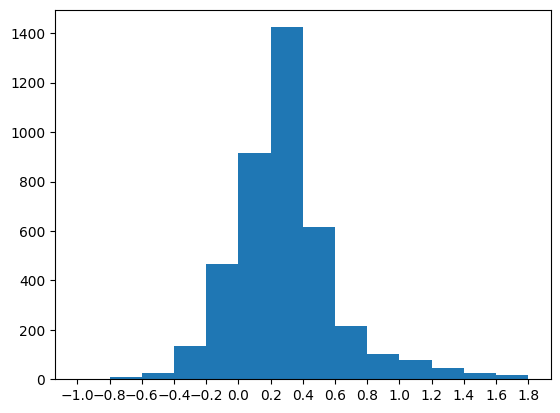

In [71]:
# distribution of plsr.predict img features
print(y_pred.shape)
IDX=10
print(np.mean(y_pred[IDX]),np.max(y_pred[IDX]),np.min(y_pred[IDX]))

d = 0.2
num_bin = np.arange(-1,2,d)
#print(max(a)-min(a),max(a),min(a))

plt.figure() # figsize=(16,6),dpi=80

plt.hist(y_pred[IDX], num_bin)
plt.xticks(num_bin)
plt.show()

(19, 4510)
(19, 4096)
(19, 4096)
(19, 4096)
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


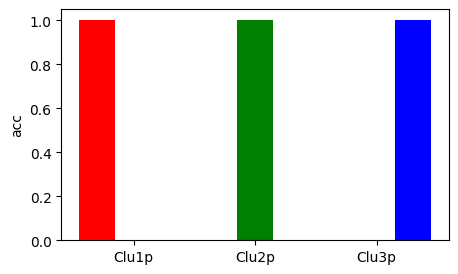

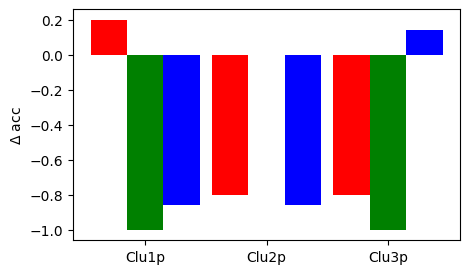

In [95]:
#3 cluster strengthen to accuracy

# id = 7
# nm = lys[id]+'_b2m_plsr_label3.npz'
# yhat_ = np.load(pjoin(fdir, lys[id], nm))
# yhat = yhat_['label'] # [0,1,2]

x_mean = np.mean(x_train,axis=0)
x = betas_concept[cat_idx2].T
x = x[mkb].T
x = x - x_mean # centerize
print(x.shape) #(30,4510) 

coef = plsr.coef_
# coef[idxm_clux] = 0
coef_clu1p = coef + 0
coef_clu1p[idxm_clu1] = 0.01
y_pred_clu1p = np.dot(x, coef_clu1p.T)
coef_clu2p = coef + 0
coef_clu2p[idxm_clu2] = 0.01
y_pred_clu2p = np.dot(x, coef_clu2p.T)
coef_clu3p = coef + 0
coef_clu3p[idxm_clu3] = 0.01
y_pred_clu3p = np.dot(x, coef_clu3p.T)

# y_pred = plsr.predict(x)
# y_pred.T[idxm_clux] = 0
# y_pred_clu1p = y_pred+0
# y_pred_clu1p.T[idxm_clu1] = 2
# y_pred_clu2p = y_pred+0
# y_pred_clu2p.T[idxm_clu2] = 2
# y_pred_clu3p = y_pred+0
# y_pred_clu3p.T[idxm_clu3] = 2

id1 = []
id2 = []
id3 = []
for i in range(cats_num.shape[0]):
    if cats_num[i] == 0:
        id1.append(i)
    if cats_num[i] == 1:
        id2.append(i)
    if cats_num[i] == 2:
        id3.append(i)

y_hat_ = [] # store lr.predict
#############################################1 img_fea_clu1x

X=y_pred_clu1p
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
y_hat_.append(y_hat)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu1p_1 = np.mean(result[id1])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_1))
acc_clu1p_2 = np.mean(result[id2])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_2))
acc_clu1p_3 = np.mean(result[id3])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_3))

################################################2 img_fea_clu2x

X=y_pred_clu2p
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
y_hat_.append(y_hat)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu2p_1 = np.mean(result[id1])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_1))
acc_clu2p_2 = np.mean(result[id2])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_2))
acc_clu2p_3 = np.mean(result[id3])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_3))

#################################################3 img_fea_clu3x

X=y_pred_clu3p
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
y_hat_.append(y_hat)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu3p_1 = np.mean(result[id1])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_1))
acc_clu3p_2 = np.mean(result[id2])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_2))
acc_clu3p_3 = np.mean(result[id3])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_3))

acc_ori = np.array([acc_ori_3,acc_ori_1,acc_ori_2])
acc_clup_ = np.array([[acc_clu2p_3,acc_clu2p_1,acc_clu2p_2],[acc_clu1p_3,acc_clu1p_1,acc_clu1p_2],[acc_clu3p_3,acc_clu3p_1,acc_clu3p_2]])
acc_clup = acc_clup_ + 0
for i in range(3):
    acc_clup[i] = acc_clup_[i] - acc_ori
print(acc_clup_)

xlb = ['Clu1p', 'Clu2p', 'Clu3p']
x = np.arange(len(xlb))
width = 0.3
ly2 = x - width
ly3 = x
ly4 = x + width

plt.figure(figsize=(5,3)) # ,dpi=300
plt.rc('font',family='Arial', size=10)
plt.bar(ly2,acc_clup_.T[0],width=width,color="red",label='Sce') # ,yerr=std_score_bm
plt.bar(ly3,acc_clup_.T[1],width=width,color="green",label='Ani')
plt.bar(ly4,acc_clup_.T[2],width=width,color="blue",label='Obj')

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('acc',fontdict=font_dict)
# plt.ylabel('$\Delta$ acc',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection') 
plt.show()

plt.figure(figsize=(5,3)) # ,dpi=300
plt.rc('font',family='Arial', size=10)
plt.bar(ly2,acc_clup.T[0],width=width,color="red",label='Sce') # ,yerr=std_score_bm
plt.bar(ly3,acc_clup.T[1],width=width,color="green",label='Ani')
plt.bar(ly4,acc_clup.T[2],width=width,color="blue",label='Obj')

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('$\Delta$ acc',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection') 
plt.show()
plt.close()

In [96]:
print(y_hat_)

[array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]), array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])]


In [ ]:
########################################################################################## PLSR and Classification end